# Authorship Attribution in the *Athenäum Fragments* Using Stylometry and Random Forest

## Project description

This notebook implements an authorship attribution system for the *Athenäum Fragments* (1798–1800),
the central publication of German Early Romanticism, whose texts were written collaboratively by
Friedrich Schlegel, August Wilhelm Schlegel, Novalis (Georg Philipp von Hardenberg) and Friedrich
Schleiermacher — in many cases without any record of individual authorship.

Performance Summary: 5-Fold Stratified Cross-Validation on 374 labeled fragments yields a Mean Macro-F1 of 0.355 (± 0.047) and an Out-of-Fold (OOF) Accuracy of 45.7% (Macro-F1: 0.359).
- Dominant Classes: Friedrich Schlegel (F1 = 0.58) and August Wilhelm Schlegel (F1 = 0.48).
- Minority Classes: Schleiermacher (F1 = 0.23) and Novalis (F1 = 0.15).

## Notebook structure

1. **Feature extraction** — Stylometric features are extracted at three levels:
   - *Basic*: text length, lexical diversity, mean word length
   - *Morphological*: frequency of definite/indefinite articles, conjunctions, subordinators, negations, modal particles
   - *Syntactic*: subjunctive mood, subordinate clauses, proportion of compound words, character n-grams
2. **Exploratory analysis** — Distribution visualisations by author and Principal Component Analysis (PCA)
3. **Pipeline definition and hyperparameter tuning** — Constructing an imbalance-aware pipeline (Standardisation, Random Oversampling, and Random Forest classification), followed by a 5-fold stratified Grid Search over 324 candidate hyperparameter configurations optimising for macro-F1.
4. **Out-of-fold validation and feature interpretation** — Evaluating the tuned pipeline across a fixed 5-fold stratified cross-validation split to compute out-of-fold predictions, generate pooled performance metrics (classification report and absolute/normalised confusion matrices), assess per-fold stability, and calculate aggregate feature importances across all five folds.
5. **Prediction** — Authorship attribution for 76 fragments of unknown or disputed authorship, with per-author probabilities

## Corpus

The training corpus comprises fragments with documented authorship from all four authors.
Fragments labelled *Disputed* (n=23) and *Unattributed* (n=53)
constitute the prediction set. Texts are drawn from the critical edition of Schlegel's works
established by Ernst Behler, Jean-Jacques Anstett and Hans Eichner (München: Schöningh/Thomas, 1958–).

## Main dependencies

`scikit-learn` · `imbalanced-learn` · `stanza` · `pandas` · `numpy` · `matplotlib` · `seaborn`

In [ ]:
# Install required dependencies
!pip install scikit-learn pandas numpy matplotlib seaborn

import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import re
from collections import Counter

# Function to download fragments
def download_fragment(number):
    url = f"https://raw.githubusercontent.com/javiermunoz-acebes/SchlegelsFragmente/main/Fragmente/Fragment_{number}.txt"
    try:
        response = requests.get(url)
        if response.status_code == 200:
            return response.text
        else:
            return None
    except:
        return None

# Download all fragments
print("Downloading fragments...")
fragment_texts = {}
for i in range(1, 452):  # Del 1 al 451
    text = download_fragment(i)
    if text:
        fragment_texts[i] = text
    if i % 50 == 0:
        print(f"Downloaded {i} fragments...")

print(f"Total fragments downloaded: {len(fragment_texts)}")

# Define attributions according to table
attributions = {
    'Friedrich': [3, 4, 10, 11, 12, 16, 17, 19, 21, 22, 23, 25, 26, 28, 31, 36, 39, 41, 43, 44, 45, 47, 48, 50, 51, 52, 53, 54, 55, 56, 61, 66, 71, 72, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 88, 89, 92, 93, 95, 96, 98, 99, 100, 102, 103, 104, 105, 108, 109, 112, 113, 114, 116, 117, 118, 119, 120, 121, 123, 124, 125, 126, 137, 138, 143, 146, 147, 148, 149, 152, 153, 154, 155, 156, 161, 164, 165, 166, 167, 168, 214, 215, 216, 217, 219, 220, 221, 222, 225, 229, 230, 231, 232, 233, 234, 235, 238, 239, 240, 242, 244, 245, 246, 247, 249, 250, 252, 253, 255, 256, 258, 262, 263, 264, 270, 272, 275, 277, 278, 281, 295, 297, 299, 300, 301, 302, 303, 304, 305, 306, 307, 318, 321, 322, 323, 325, 326, 327, 339, 342, 343, 344, 345, 346, 347, 348, 349, 357, 358, 359, 360, 365, 366, 367, 368, 369, 370, 372, 373, 375, 376, 377, 379, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 395, 397, 398, 399, 400, 401, 402, 403, 404, 406, 408, 409, 411, 412, 414, 415, 418, 419, 420, 421, 424, 426, 427, 429, 430, 431, 432, 434, 435, 437, 438, 439, 440, 443, 444, 445, 449, 450, 451],

    'August': [6, 7, 8, 9, 14, 18, 20, 40, 58, 59, 60, 106, 110, 122, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 140, 141, 142, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 197, 198, 199, 200, 201, 202, 203, 204, 205, 207, 208, 209, 210, 212, 224, 236, 237, 241, 243, 254, 257, 260, 261, 269, 271, 309, 310, 311, 313, 314, 405],

    'Novalis': [282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294],

    'Schleiermacher': [35, 37, 38, 42, 46, 49, 62, 63, 64, 65, 67, 68, 69, 70, 73, 85, 87, 90, 91, 94, 97, 101, 107, 111, 139, 279, 280, 328, 329, 330, 331, 334, 335, 336, 337, 338, 340, 341, 350, 351, 352, 353, 354, 355, 356, 362, 364, 371, 407, 428],

    'August_Friedrich': [259, 273],

    'Disputed': [2, 57, 86, 115, 144, 145, 150, 151, 157, 158, 159, 160, 162, 163, 276, 296, 312, 333, 361, 378, 380, 394, 423],

    'Unattributed': [1, 5, 13, 15, 24, 27, 29, 30, 32, 33, 34, 110, 196, 206, 211, 213, 218, 223, 226, 227, 228, 248, 251, 265, 266, 267, 268, 274, 298, 308, 315, 316, 317, 319, 320, 324, 332, 363, 374, 396, 410, 413, 416, 417, 422, 425, 433, 436, 441, 442, 446, 447, 448]
}

# Create inverse mapping: fragment -> author
fragment_to_author = {}
for author, fragments in attributions.items():
    for fragment in fragments:
        fragment_to_author[fragment] = author

# Prepare training data (only fragments with clear attribution)
training_authors = ['August', 'Novalis', 'Schleiermacher', 'Friedrich']  # Exclude disputed and unattributed
training_texts = []
training_labels = []

for author in training_authors:
    for fragment_num in attributions[author]:
        if fragment_num in fragment_texts:
            training_texts.append(fragment_texts[fragment_num])
            training_labels.append(author)

print(f"\nFragments for training: {len(training_texts)}")
print(f"Distribution by author:")
for author in training_authors:
    count = training_labels.count(author)
    print(f"  {author}: {count} fragments")

# Verify that we have sufficient data
if len(training_texts) == 0:
    print("ERROR: Could not load fragments for training")
    print("Verifying available fragments...")
    print(f"Downloaded fragments: {list(fragment_texts.keys())[:10]}...")  # Show first 10
else:
    print("✓ Training data successfully prepared")

Downloaded 50 fragments...
Downloaded 100 fragments...
Downloaded 150 fragments...
Downloaded 200 fragments...
Downloaded 250 fragments...
Downloaded 300 fragments...
Downloaded 350 fragments...
Downloaded 400 fragments...
Downloaded 450 fragments...
Total fragments downloaded: 451

Fragments for training: 374
Distribution by author:
  August: 85 fragments
  Novalis: 13 fragments
  Schleiermacher: 50 fragments
  Friedrich: 226 fragments
✓ Training data successfully prepared


## **1. Feature extraction**

In [ ]:
# Manual stylometric feature extraction
import re
import pandas as pd

def extract_manual_features(text):
    """Extract hand-engineered regex and character/word-level stylometric features."""
    f = {}
    total_chars = max(len(text), 1)
    words = re.findall(r"\b\w+\b", text.lower())
    total_words = max(len(words), 1)

    # Basic length metrics
    f["char_count"] = len(text)
    f["word_count"] = len(words)
    f["avg_word_length"] = sum(len(w) for w in words) / total_words if words else 0

    sentences = [s.strip() for s in re.split(r"[.!?]+", text) if s.strip()]
    sentence_count = max(len(sentences), 1)
    f["sentence_count"] = sentence_count
    f["avg_sentence_length"] = total_words / sentence_count
    f["ttr_lexical_diversity"] = len(set(words)) / total_words
    f["long_words_ratio"] = sum(1 for w in words if len(w) > 6) / total_words

    long_sentences = [s for s in sentences if len(s.split()) > 20]
    interrogative_sentences = [s for s in sentences if s.endswith("?")]
    f["long_sentences_ratio"] = len(long_sentences) / sentence_count
    f["interrogative_sentences_ratio"] = len(interrogative_sentences) / sentence_count

    # Punctuation frequencies
    f["freq_commas"] = text.count(",") / total_chars
    f["freq_periods"] = text.count(".") / total_chars
    f["freq_semicolons"] = text.count(";") / total_chars
    f["freq_colons"] = text.count(":") / total_chars
    f["freq_question_marks"] = text.count("?") / total_chars
    f["freq_exclamation_marks"] = text.count("!") / total_chars
    f["freq_parentheses"] = (text.count("(") + text.count(")")) / total_chars
    f["freq_quotes"] = (text.count('"') + text.count("'") + text.count("»") + text.count("«")) / total_chars
    f["freq_dashes"] = (text.count("-") + text.count("—")) / total_chars
    f["uppercase_ratio"] = sum(1 for c in text if c.isupper()) / total_chars
    f["digit_ratio"] = sum(1 for c in text if c.isdigit()) / total_chars

    def word_freq(patterns):
        return sum(words.count(p) for p in patterns) / total_words

    # Closed-class and functional word groups
    f["freq_def_articles"] = word_freq(["der", "die", "das", "des", "dem", "den"])
    f["freq_indef_articles"] = word_freq(["ein", "eine", "eines", "einem", "einen", "einer"])
    f["freq_coordinating_conj"] = word_freq(["und", "oder", "aber", "denn", "sondern", "allein"])
    f["freq_subordinating_conj"] = word_freq(["weil", "da", "dass", "daß", "wenn", "obgleich", "ob", "nachdem", "ehe"])
    f["freq_negations"] = word_freq(["nicht", "nie", "niemals", "kein", "keine", "keines", "weder"])
    f["freq_modal_particles"] = word_freq(["ja", "doch", "wohl", "eben", "gar", "etwa", "halt", "schon"])
    f["freq_pron_1st_sing"] = word_freq(["ich", "mich", "mir", "meiner", "mein", "meine", "meines", "meinem", "meinen"])
    f["freq_pron_1st_plur"] = word_freq(["wir", "uns", "unser", "unsere", "unseres", "unserm", "unserem", "unserer", "unseren"])
    f["freq_pron_2nd"] = word_freq(["du", "dich", "dir", "deiner", "dein", "deine", "deines", "deinem", "deinen", "ihr", "euch", "euer", "eure", "eures", "eurem", "eurer", "euren"])
    f["freq_pron_3rd"] = word_freq(["er", "ihn", "ihm", "sie", "ihrer", "es", "ihnen", "sein", "seine", "seines", "seinem", "seinen", "ihr", "ihres", "ihrem", "ihren"])
    f["freq_possessives"] = word_freq(["mein", "dein", "sein", "ihr", "unser", "euer"])
    f["freq_prepositions"] = word_freq(["in", "an", "auf", "für", "von", "mit", "zu", "bei", "nach", "aus"])
    f["freq_aux_sein"] = word_freq(["ist", "sind", "war", "waren", "sei", "seien", "gewesen"])
    f["freq_aux_haben"] = word_freq(["hat", "haben", "hatte", "hatten", "hätte", "gehabt"])
    f["freq_aux_werden"] = word_freq(["wird", "werden", "wurde", "wurden", "würde", "geworden"])
    f["freq_modal_verbs"] = word_freq(["kann", "können", "muss", "müssen", "muß", "soll", "sollen", "will", "wollen", "darf", "dürfen", "mag", "mögen"])
    f["freq_relative_pron"] = word_freq(["welche", "welcher", "welches"])
    f["freq_demonstratives"] = word_freq(["dieser", "diese", "dieses", "jenes", "jener", "jene"])

    # Morphological and structural markers
    f["compound_words_ratio"] = sum(1 for w in words if "-" in w or len(w) >= 12) / total_words
    f["inversion_indicators"] = len(re.findall(r"\b(denn|doch|daher|mithin|zwar)\s+[a-zäöü]+\s+[a-zäöü]+", text.lower())) / sentence_count
    f["freq_char_ngram_ch"] = text.lower().count("ch") / total_chars
    f["freq_char_ngram_sch"] = text.lower().count("sch") / total_chars
    f["freq_char_ngram_ung"] = text.lower().count("ung") / total_chars
    f["freq_char_ngram_heit_keit"] = (text.lower().count("heit") + text.lower().count("keit")) / total_chars

    # Lexical / Discourse frequencies (using token matching to avoid substring collision)
    REFLEXIVES = {"sich", "mich", "dich", "uns", "euch"}
    CONNECTORS = {"also", "doch", "denn", "jedoch", "deshalb", "obgleich", "obwohl"}
    ABSTRACT_WORDS = {"freiheit", "vernunft", "idee", "kunst", "religion", "sinn", "geist"}
    RELIGIOUS_WORDS = {"gott", "himmel", "christus", "glaube", "mysterien", "kirche"}
    f["freq_reflexives"] = sum(1 for w in words if w in REFLEXIVES) / total_words
    f["freq_connectors"] = sum(1 for w in words if w in CONNECTORS) / total_words
    f["freq_abstract"] = sum(1 for w in words if w in ABSTRACT_WORDS) / total_words
    f["freq_religious"] = sum(1 for w in words if w in RELIGIOUS_WORDS) / total_words

    return f


In [ ]:
# Stanza feature extraction (additional syntactic features)
!pip -q install stanza
import stanza
from tqdm.auto import tqdm

stanza.download("de")
nlp = stanza.Pipeline(lang="de", processors="tokenize,mwt,pos,lemma,depparse", verbose=False)

def extract_stanza_features(text):
    """Extract syntactic, morphological, and POS features using a single Stanza pass."""
    doc = nlp(text)
    num_sentences = max(len(doc.sentences), 1)

    subjunctive_count = 0
    subordinate_count = 0
    lexical_count = 0
    adjectives = 0
    adverbs = 0
    future_verbs = 0
    passive_verbs = 0
    total_tokens = 0

    for sent in doc.sentences:
        for word in sent.words:
            total_tokens += 1

            # UPOS features
            if word.upos == "ADJ":
                adjectives += 1
            elif word.upos == "ADV":
                adverbs += 1

            if word.upos in {"NOUN", "VERB", "ADJ", "ADV"}:
                lexical_count += 1

            # Dependency parsing
            if word.deprel in {"mark", "advcl", "csubj", "acl", "ccomp", "xcomp"}:
                subordinate_count += 1

            # Morphological features
            if word.feats:
                if "Mood=Sub" in word.feats:
                    subjunctive_count += 1
                if "Tense=Fut" in word.feats:
                    future_verbs += 1
                if "Voice=Pass" in word.feats:
                    passive_verbs += 1

    denom = max(total_tokens, 1)
    return {
        # Syntactic clause features
        # "subjunctive_count": subjunctive_count,
        # "subordinate_count": subordinate_count,
        "subjunctive_ratio": subjunctive_count / num_sentences,
        "subordinate_ratio": subordinate_count / num_sentences,
        "lexical_density": lexical_count / denom,
        # Morphosyntactic features
        "adjective_ratio": adjectives / denom,
        "adverb_ratio": adverbs / denom,
        "future_tense_ratio": future_verbs / denom,
        "passive_voice_ratio": passive_verbs / denom,
    }

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 21.1 MB/s eta 0:00:00


INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Downloading default packages for language: de (German) ...


models/default.zip: reconstructing file:   0%|          |  0.00B /  809MB            

models/default.zip: downloading bytes:           |  0.00B            

INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/de/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.14.0/resources


In [ ]:
# Extract ALL features once
print("Extracting manual + Stanza features...")
rows = []
for text in tqdm(training_texts, desc="Feature extraction"):
    row = extract_manual_features(text)
    row.update(extract_stanza_features(text))
    rows.append(row)

df_features = pd.DataFrame(rows)
assert len(df_features) == len(training_texts) == len(training_labels)
# assert df_features.shape[1] == 52, f"Expected 52 features, got {df_features.shape[1]}"

# Keep labels separately; never overwrite df_features later.
feature_names = df_features.columns.tolist()
print(f"Feature matrix: {df_features.shape[0]} texts x {df_features.shape[1]} features")
print(f"Total: {len(feature_names)}")
# print("Stanza features:", [c for c in feature_names if c.startswith("stanza_")])

Extracting manual + Stanza features...


Feature extraction:   0%|          | 0/374 [00:00<?, ?it/s]

Feature matrix: 374 texts x 55 features
Total: 55


In [ ]:
print("Stylometric features extracted:")
print(df_features.head())

Stylometric features extracted:
   char_count  word_count  avg_word_length  sentence_count  \
0         292          45         5.311111               2   
1          91          15         4.866667               2   
2         172          25         5.720000               1   
3         150          27         4.444444               1   
4         646          88         6.170455               5   

   avg_sentence_length  ttr_lexical_diversity  long_words_ratio  \
0                 22.5               0.933333          0.266667   
1                  7.5               0.866667          0.200000   
2                 25.0               1.000000          0.320000   
3                 27.0               0.851852          0.111111   
4                 17.6               0.875000          0.363636   

   long_sentences_ratio  interrogative_sentences_ratio  freq_commas  ...  \
0                   0.5                            0.0     0.013699  ...   
1                   0.0                 

## **2. Exploratory Analysis**

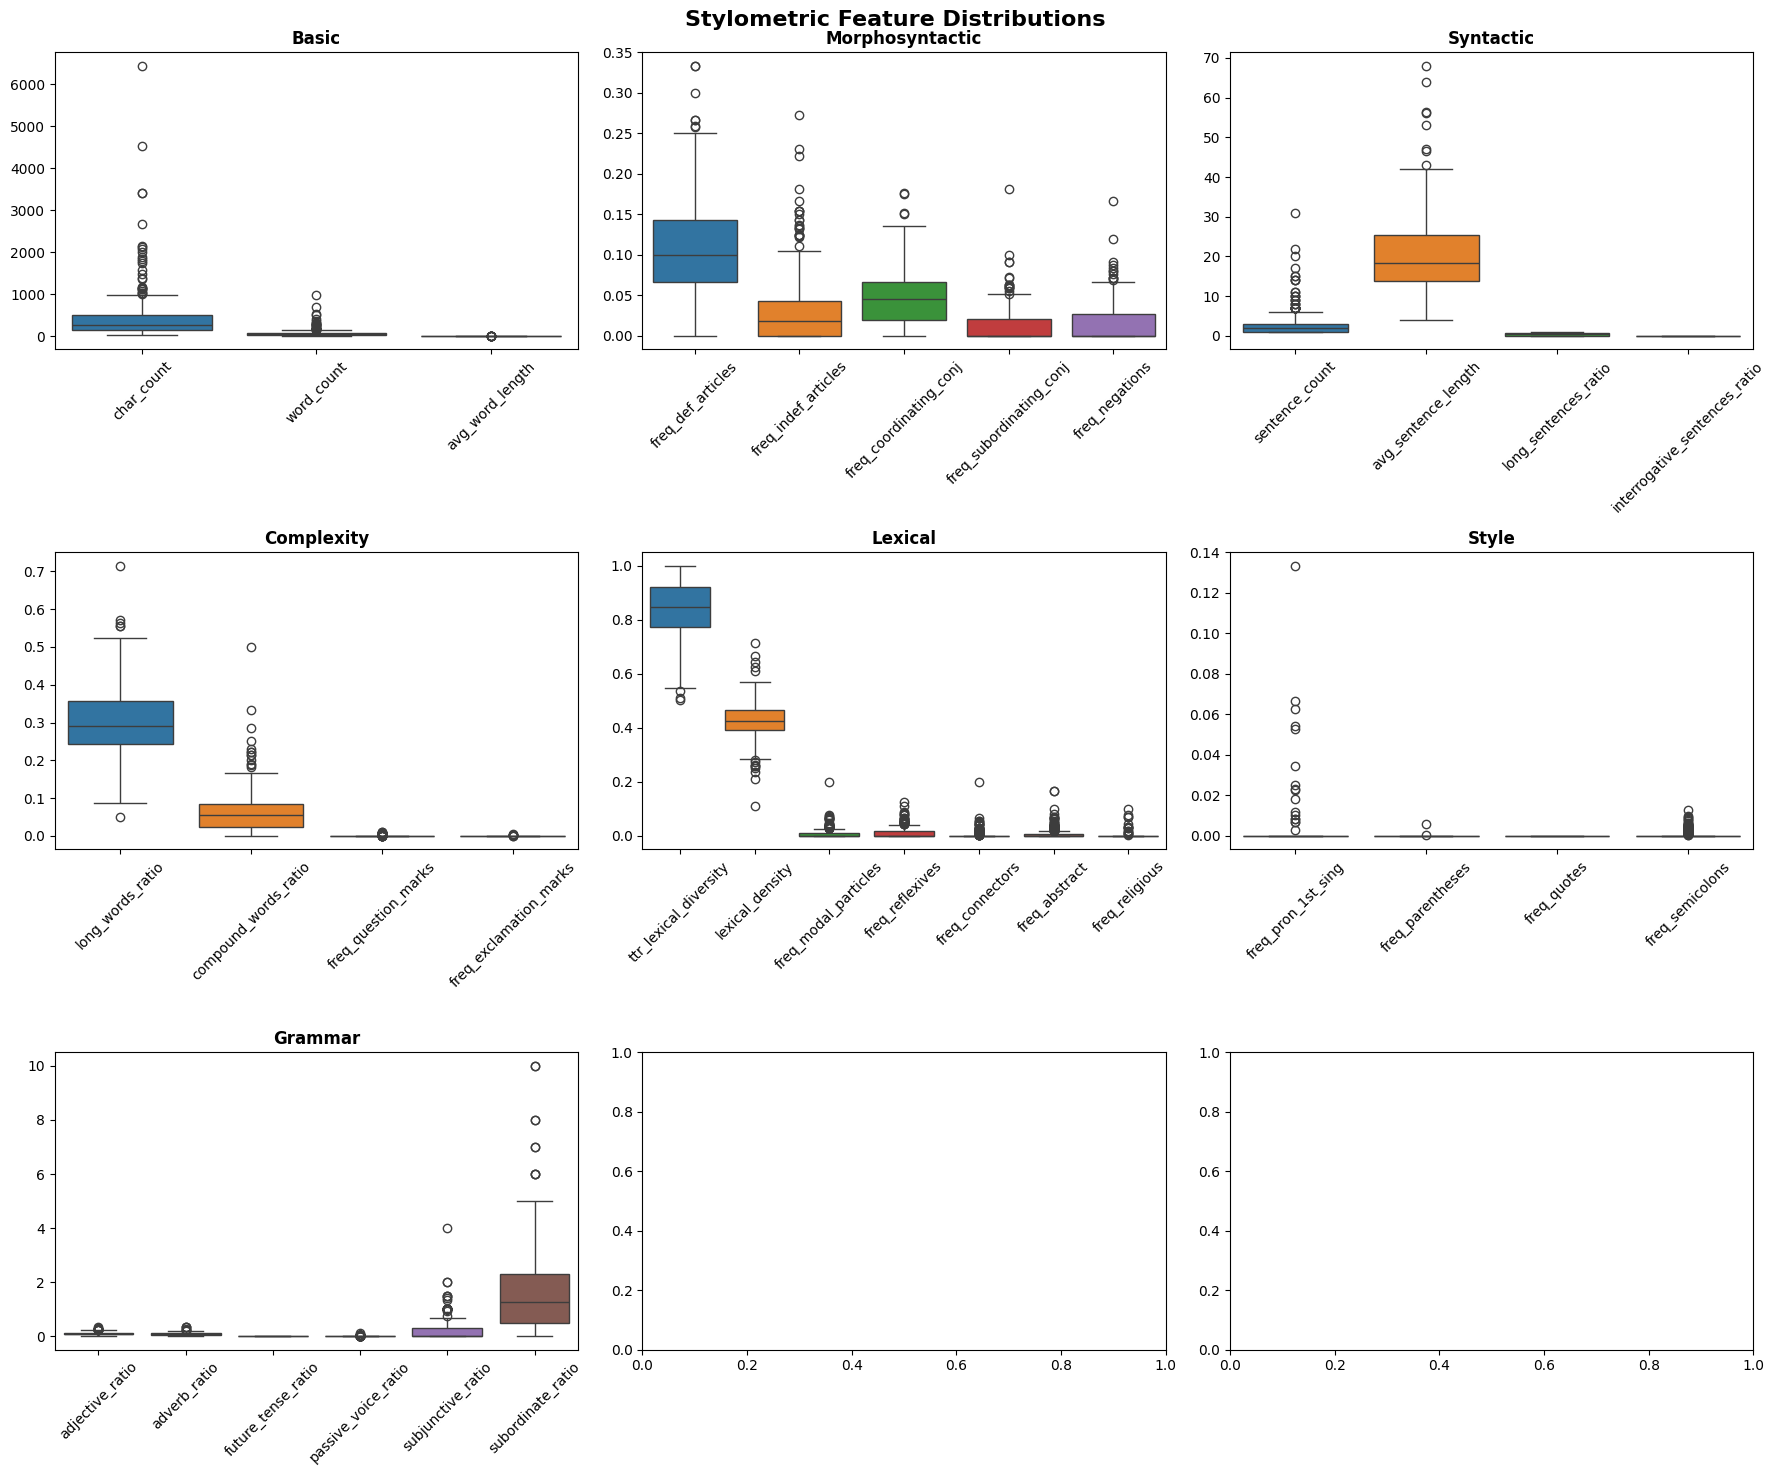

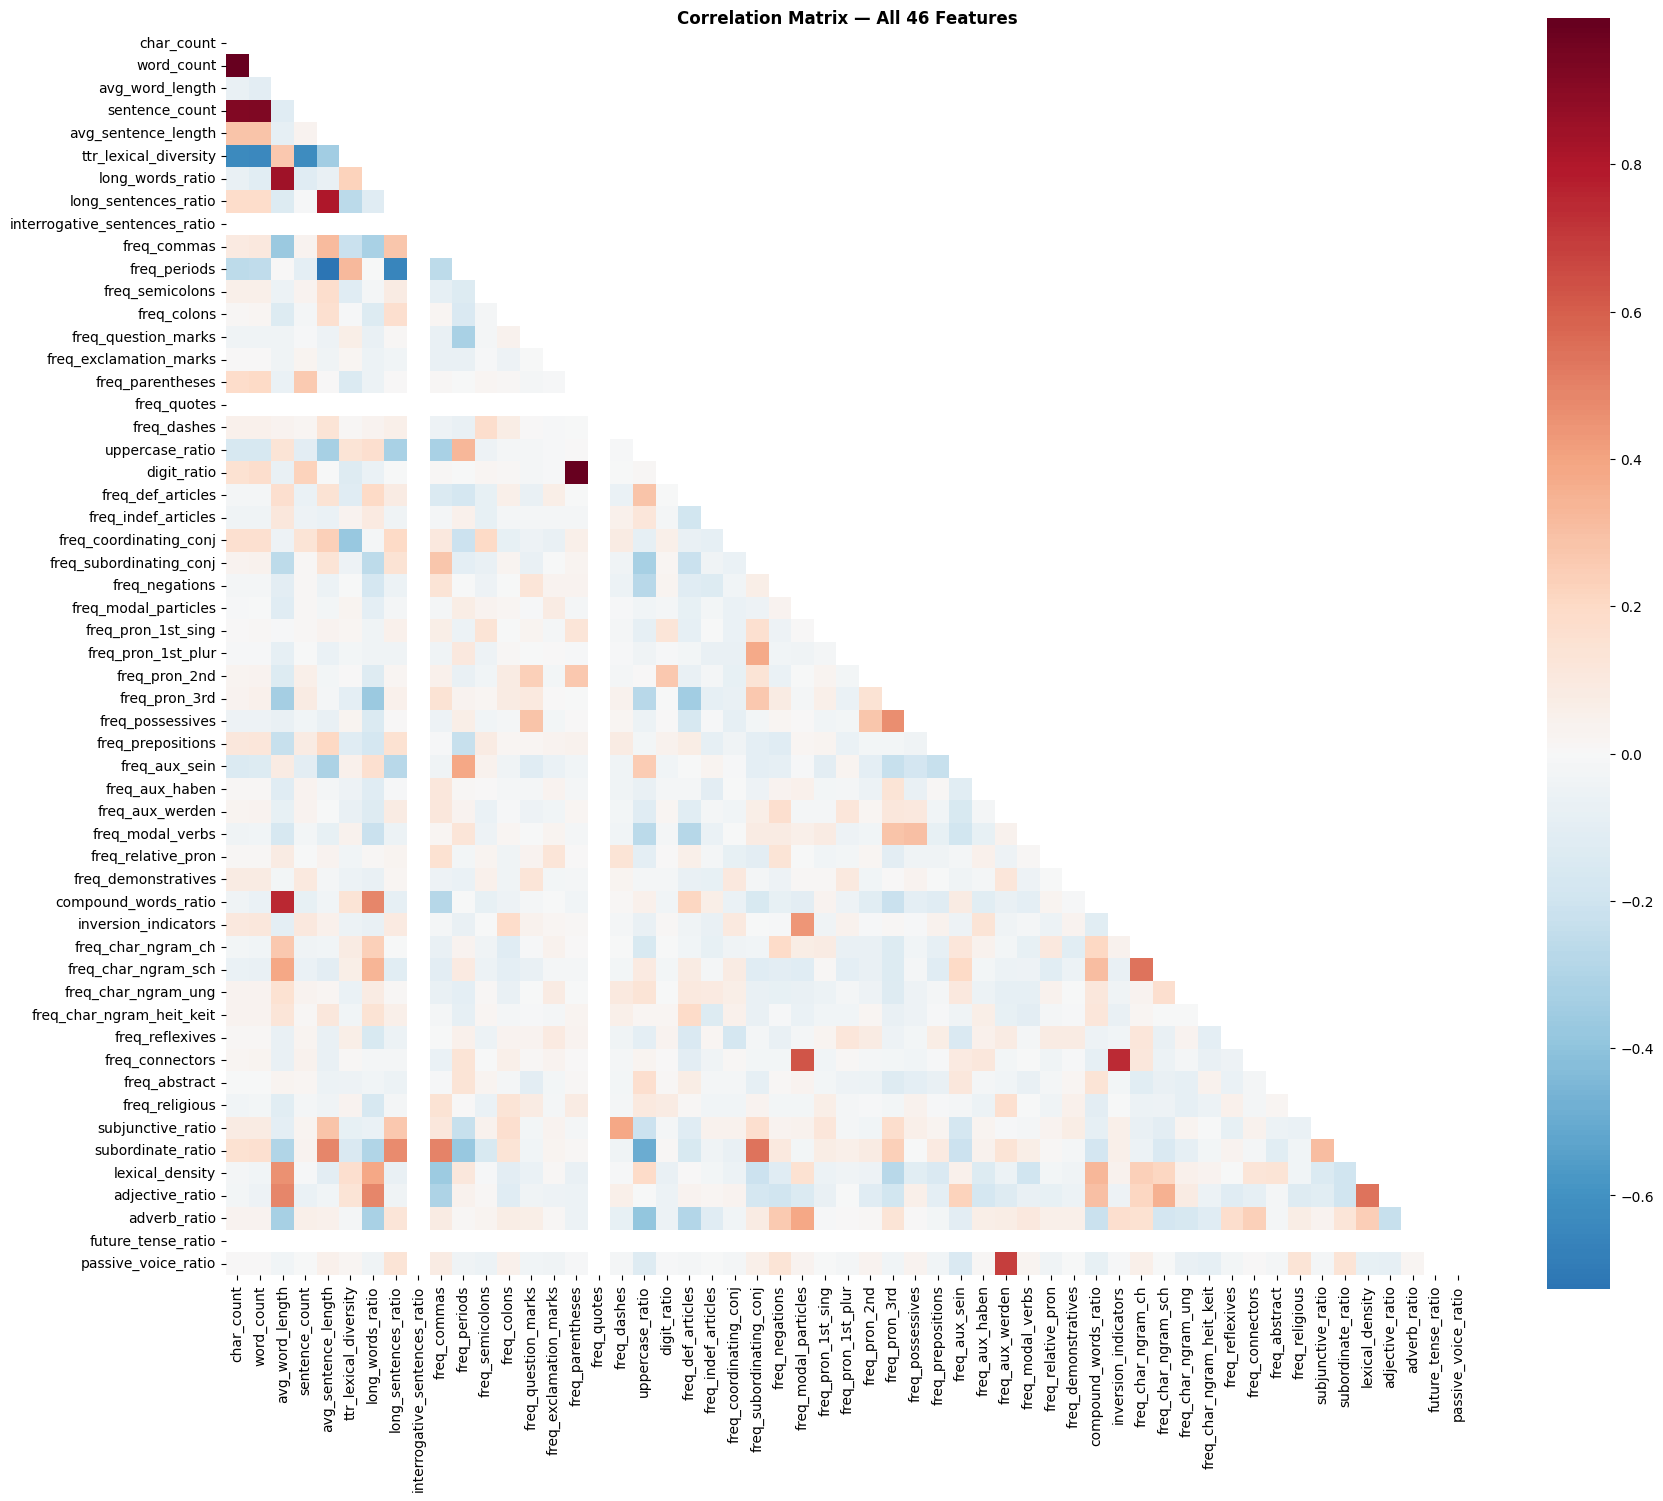

In [ ]:
# EDA 1 — Feature distributions
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plot_groups = {
    "Basic": ["char_count", "word_count", "avg_word_length"],
    "Morphosyntactic": ["freq_def_articles", "freq_indef_articles", "freq_coordinating_conj", "freq_subordinating_conj", "freq_negations"],
    "Syntactic": ["sentence_count", "avg_sentence_length", "long_sentences_ratio", "interrogative_sentences_ratio"],
    "Complexity": ["long_words_ratio", "compound_words_ratio", "freq_question_marks", "freq_exclamation_marks"],
    "Lexical": ["ttr_lexical_diversity", "lexical_density", "freq_modal_particles", "freq_reflexives", "freq_connectors", "freq_abstract", "freq_religious"],
    "Style": ["freq_pron_1st_sing", "freq_parentheses", "freq_quotes", "freq_semicolons"],
    "Grammar": ["adjective_ratio", "adverb_ratio", "future_tense_ratio", "passive_voice_ratio", "subjunctive_ratio", "subordinate_ratio"]
}

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
for ax, (title, cols) in zip(axes.flat, plot_groups.items()):
    sns.boxplot(data=df_features[cols], ax=ax)
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("Stylometric Feature Distributions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("01_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA 2 — Correlation matrix
plt.figure(figsize=(18, 15))
correlation_matrix = df_features.corr(numeric_only=True)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, cmap="RdBu_r", center=0, fmt=".2f", square=True)
plt.title("Correlation Matrix — All 46 Features", fontweight="bold")
plt.tight_layout()
plt.savefig("02_feature_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


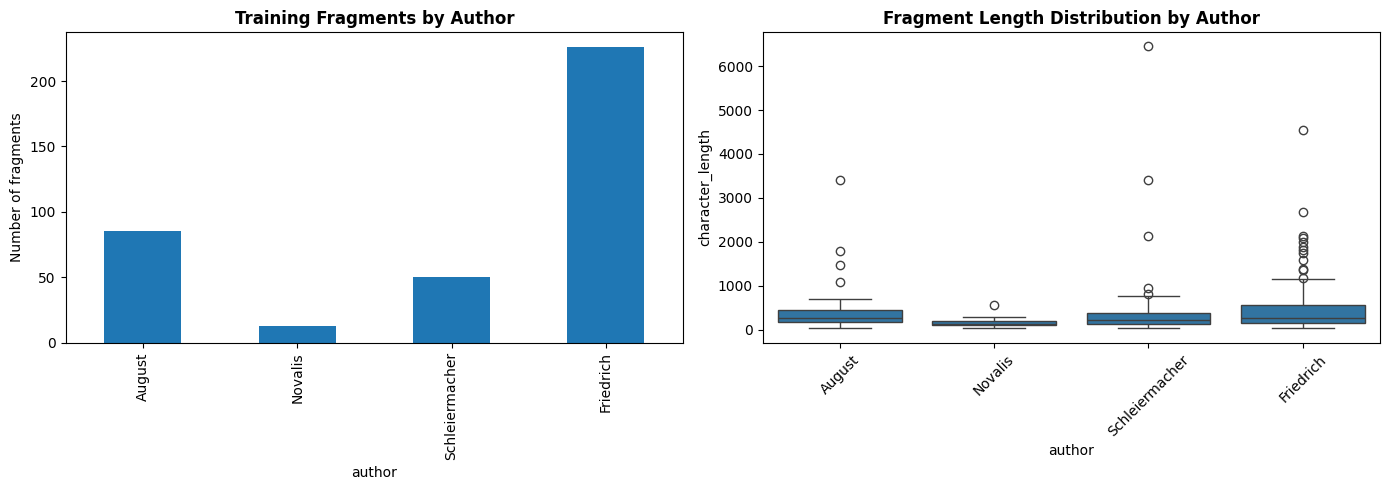

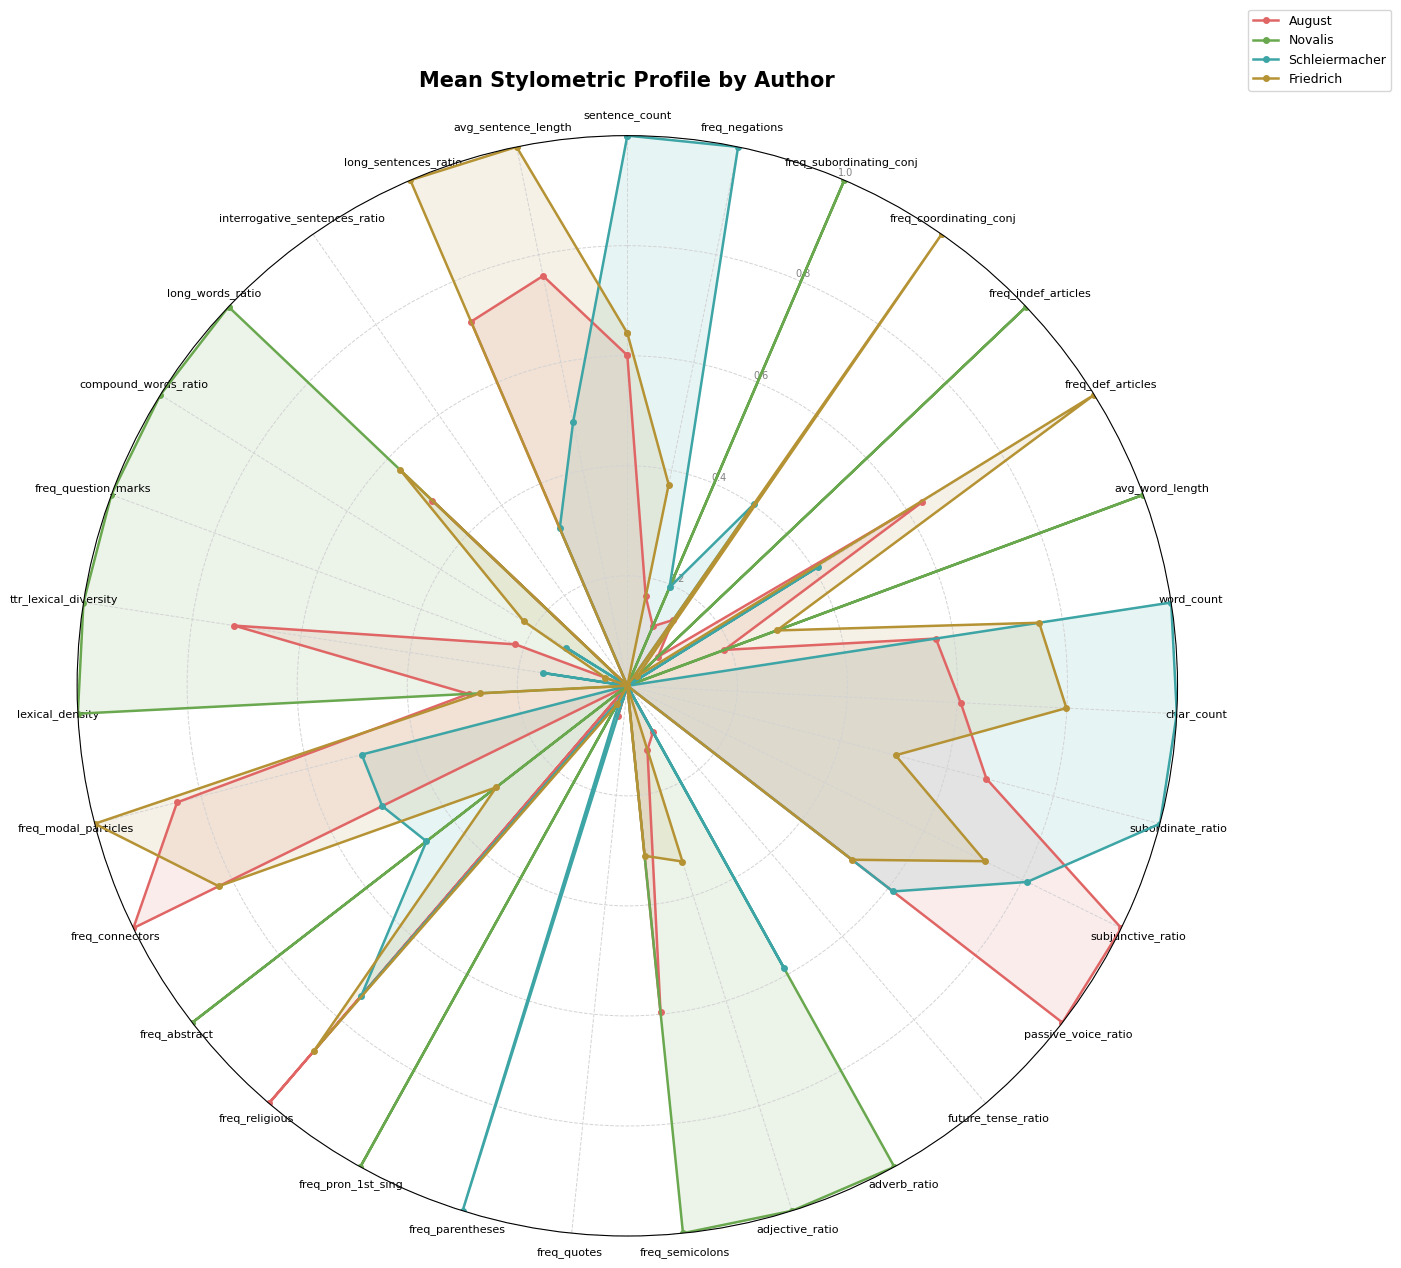

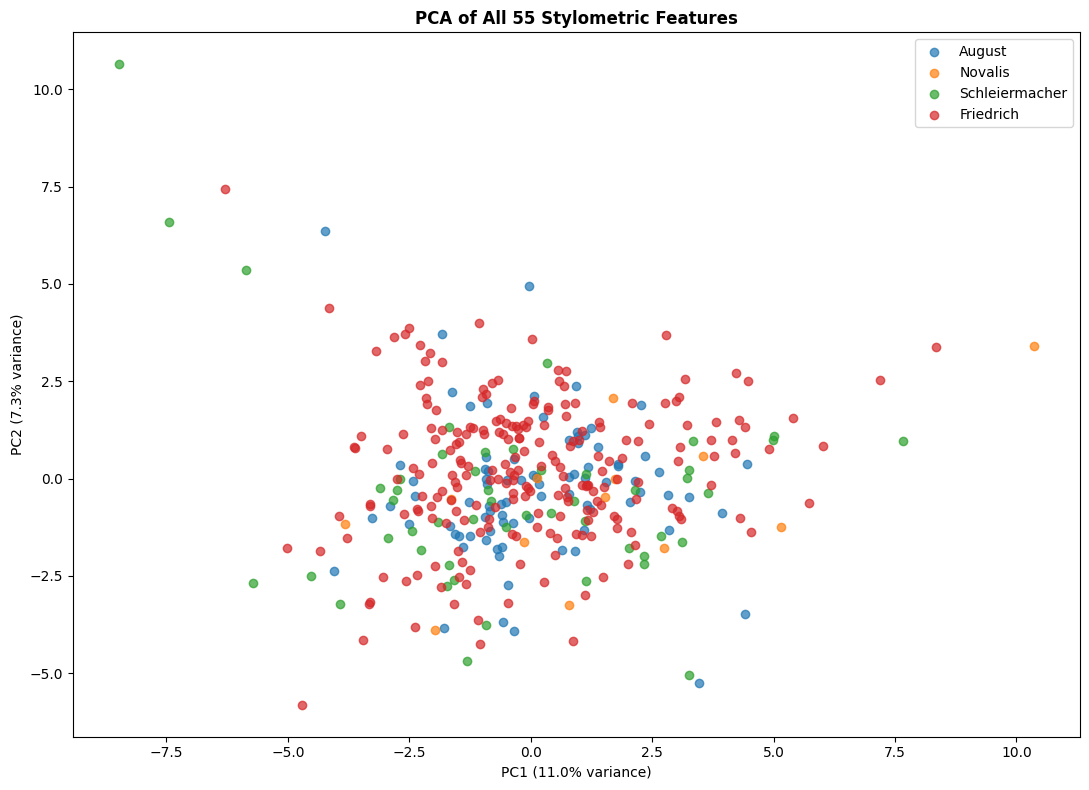

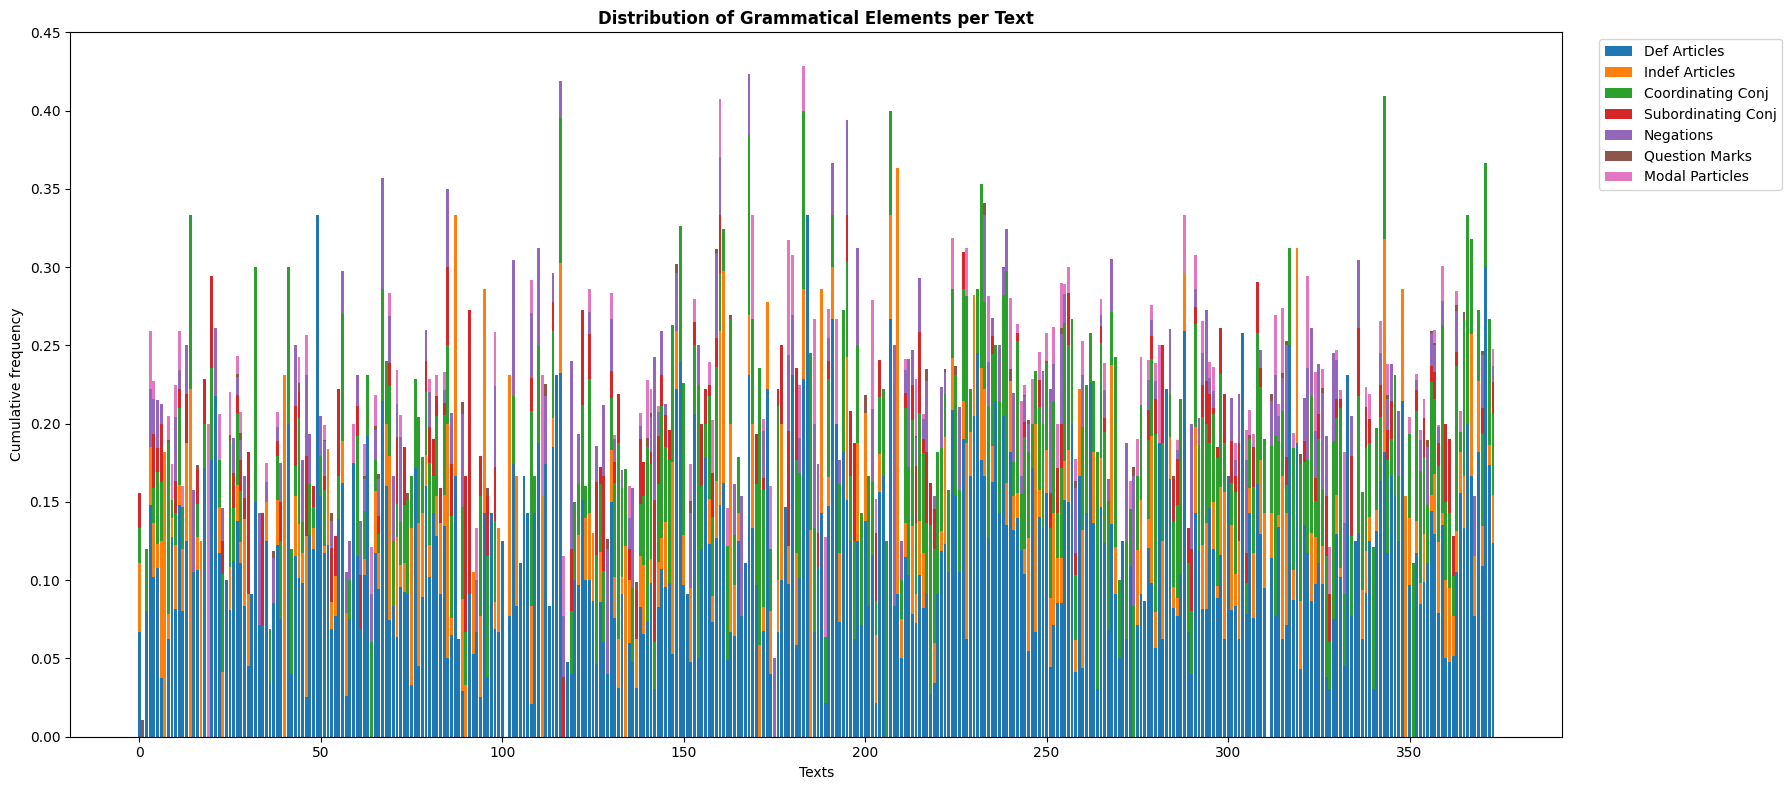

,count,mean,std,min,25%,50%,75%,max
char_count,374.0,421.2594,575.1618,33.0000,155.7500,264.5000,497.2500,6445.0000
word_count,374.0,62.6150,86.3902,5.0000,23.0000,39.0000,73.0000,973.0000
avg_word_length,374.0,5.6136,0.6622,3.9500,5.1854,5.5314,5.9593,9.5000
sentence_count,374.0,2.9733,3.1698,1.0000,1.0000,2.0000,3.0000,31.0000
avg_sentence_length,374.0,20.7288,9.6830,4.0000,13.8701,18.3333,25.5000,68.0000
ttr_lexical_diversity,374.0,0.8412,0.1053,0.5036,0.7732,0.8473,0.9231,1.0000
long_words_ratio,374.0,0.2996,0.0917,0.0500,0.2425,0.2915,0.3562,0.7143
long_sentences_ratio,374.0,0.4157,0.3876,0.0000,0.0000,0.4000,0.6747,1.0000
interrogative_sentences_ratio,374.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
freq_commas,374.0,0.0122,0.0068,0.0000,0.0078,0.0124,0.0165,0.0355


In [ ]:

# EDA 3 — Author distributions and fragment lengths
eda_df = df_features.copy()
eda_df["author"] = training_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eda_df["author"].value_counts().reindex(training_authors).plot(kind="bar", ax=axes[0])
axes[0].set_title("Training Fragments by Author", fontweight="bold")
axes[0].set_ylabel("Number of fragments")

lengths = pd.DataFrame({
    "author": training_labels,
    "character_length": [len(t) for t in training_texts]
})
sns.boxplot(data=lengths, x="author", y="character_length", ax=axes[1])
axes[1].set_title("Fragment Length Distribution by Author", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("03_author_and_length_eda.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA 4 — Mean stylometric profiles by author (representative features)
radar_features = ["sentence_count", "freq_negations", "freq_subordinating_conj",
    "freq_coordinating_conj", "freq_indef_articles", "freq_def_articles",
    "avg_word_length", "word_count", "char_count", "subordinate_ratio",
    "subjunctive_ratio", "passive_voice_ratio", "future_tense_ratio",
    "adverb_ratio", "adjective_ratio", "freq_semicolons", "freq_quotes",
    "freq_parentheses", "freq_pron_1st_sing", "freq_religious", "freq_abstract",
    "freq_connectors", "freq_modal_particles", "lexical_density", "ttr_lexical_diversity",
    "freq_question_marks", "compound_words_ratio", "long_words_ratio",
    "interrogative_sentences_ratio", "long_sentences_ratio", "avg_sentence_length"
]
means = eda_df.groupby("author")[radar_features].mean().reindex(training_authors)
norm = (means - means.min()) / (means.max() - means.min() + 1e-9)
num_vars = len(radar_features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
author_colors = {
    "August": "#E06666",
    "Friedrich": "#B59334",
    "Novalis": "#6AA84F",
    "Schleiermacher": "#3DA5A5",
}
fig, ax = plt.subplots(figsize=(14, 14), subplot_kw={"projection": "polar"})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
for author in norm.index:
    vals = norm.loc[author].tolist()
    vals += vals[:1]
    color = author_colors.get(author, None)

    ax.plot(
        angles, vals, marker="o", markersize=4, linewidth=1.8, label=author, color=color
    )
    ax.fill(angles, vals, color=color, alpha=0.12)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, size=8, ha="center")
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], size=7, color="gray")
ax.grid(color="lightgray", linestyle="--", linewidth=0.7)
ax.set_title("Mean Stylometric Profile by Author", fontweight="bold", fontsize=15, pad=35)
ax.legend(loc="upper right", bbox_to_anchor=(1.20, 1.12), frameon=True, fontsize=9)
plt.tight_layout()
plt.savefig("04_author_radar.png", dpi=300, bbox_inches="tight")
plt.show()

# EDA 5 — PCA of the complete feature matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X_scaled_eda = StandardScaler().fit_transform(df_features)
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled_eda)
plt.figure(figsize=(11, 8))
for author in training_authors:
    mask_author = np.array(training_labels) == author
    plt.scatter(components[mask_author, 0], components[mask_author, 1], label=author, alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of All 55 Stylometric Features", fontweight="bold")
plt.legend(); plt.tight_layout(); plt.savefig("05_pca_all_features.png", dpi=300, bbox_inches="tight"); plt.show()

# EDA 6 — Stacked grammatical frequencies (same idea as the original shell)
grammatical_cols = ["freq_def_articles", "freq_indef_articles", "freq_coordinating_conj", "freq_subordinating_conj", "freq_negations", "freq_interrogatives" if "freq_interrogatives" in df_features else "freq_question_marks", "freq_modal_particles"]
plt.figure(figsize=(18, 8))
bottom = np.zeros(len(df_features))
for col in grammatical_cols:
    vals = df_features[col].to_numpy()
    plt.bar(np.arange(len(vals)), vals, bottom=bottom, label=col.replace("freq_", "").replace("_", " ").title())
    bottom += vals
plt.xlabel("Texts"); plt.ylabel("Cumulative frequency"); plt.title("Distribution of Grammatical Elements per Text", fontweight="bold"); plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.savefig("06_stacked_grammatical_distribution.png", dpi=300, bbox_inches="tight"); plt.show()

# EDA 7 — Descriptive statistics
display(df_features.describe().T.round(4))

## **3. Pipeline definition and hyperparameter tuning**

In [ ]:
# balanced random forest classifier > better
from sklearn.base import clone
from imblearn.ensemble import BalancedRandomForestClassifier

X = df_features.copy()
y = np.array(training_labels)
feature_names = X.columns if hasattr(X, "columns") else [f"f{i}" for i in range(X.shape[1])]

# Pick hyperparameters once, on the full dataset
base_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    # ("oversample", RandomOverSampler(random_state=42)),
    ("rf", BalancedRandomForestClassifier(random_state=42))
])

param_grid = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [5, 8, 10, None],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    # "rf__class_weight": ["balanced", "balanced_subsample", None],
}

tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
grid_search = GridSearchCV(base_pipeline, param_grid, cv=tuning_cv,
                            scoring="f1_macro", n_jobs=-1, verbose=0)
grid_search.fit(X, y)
best_params = grid_search.best_params_
print("Selected hyperparameters:", best_params)

pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    # ("oversample", RandomOverSampler(random_state=42)),
    ("rf", BalancedRandomForestClassifier(
        random_state=42,
        n_estimators=best_params["rf__n_estimators"],
        max_depth=best_params["rf__max_depth"],
        min_samples_split=best_params["rf__min_samples_split"],
        min_samples_leaf=best_params["rf__min_samples_leaf"],
        # class_weight=best_params["rf__class_weight"],
    ))
])

best_model = clone(pipeline)
best_model.fit(X, y)

Selected hyperparameters: {'rf__max_depth': 8, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}


## **4. Out-of-fold validation and feature interpretation**

Fold 0: macro-F1 = 0.434
Fold 1: macro-F1 = 0.337
Fold 2: macro-F1 = 0.330
Fold 3: macro-F1 = 0.295
Fold 4: macro-F1 = 0.378

Mean macro-F1: 0.355  (± 0.047)

--- 5-fold stratified CV, out-of-fold predictions on full dataset ---
NOTE: hyperparameters were tuned on the full dataset (same data used
for OOF evaluation), so this estimate is mildly optimistic relative
to the nested-CV estimate — treat it as a stability/diagnostic check,
not the headline generalization number.
Accuracy: 0.457
Macro-F1: 0.359
                precision    recall  f1-score   support

        August       0.47      0.48      0.48        85
     Friedrich       0.72      0.49      0.58       226
       Novalis       0.09      0.38      0.15        13
Schleiermacher       0.19      0.30      0.23        50

      accuracy                           0.46       374
     macro avg       0.37      0.41      0.36       374
  weighted avg       0.57      0.46      0.50       374

[[ 41  22   7  15]
 [ 40 110  32  44]
 [ 

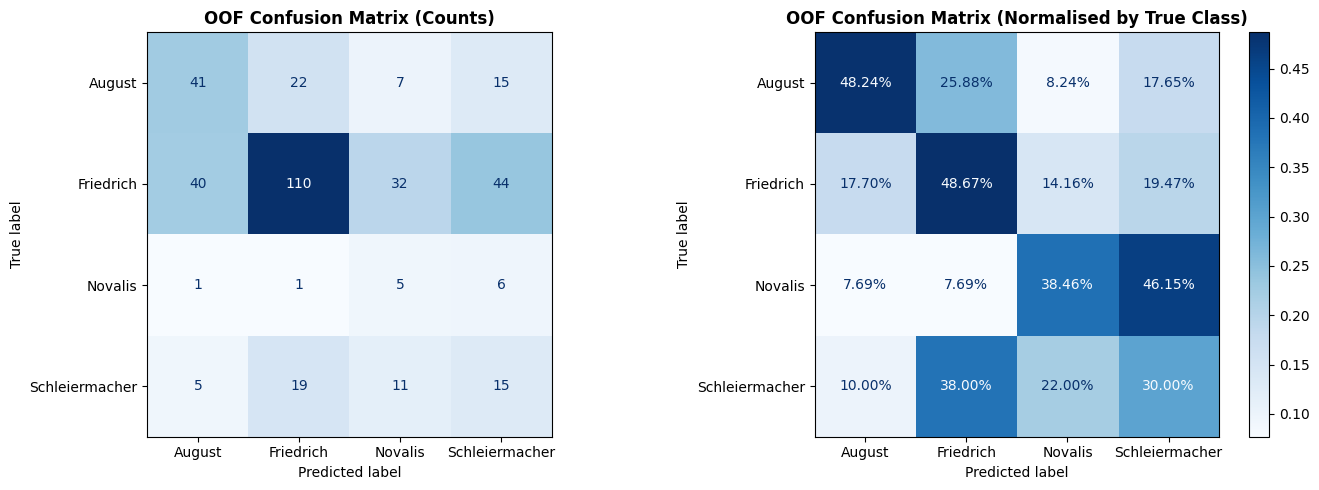


Top 20 features (permutation importance, mean ± SD across folds):


,mean_importance,std_importance
ttr_lexical_diversity,0.051045,0.018431
freq_coordinating_conj,0.048804,0.026414
freq_char_ngram_ung,0.015632,0.025534
word_count,0.009203,0.021274
compound_words_ratio,0.008413,0.026992
freq_aux_sein,0.007952,0.007871
freq_prepositions,0.007246,0.009192
uppercase_ratio,0.006572,0.014515
freq_pron_1st_plur,0.006046,0.015954
freq_modal_verbs,0.004907,0.011224


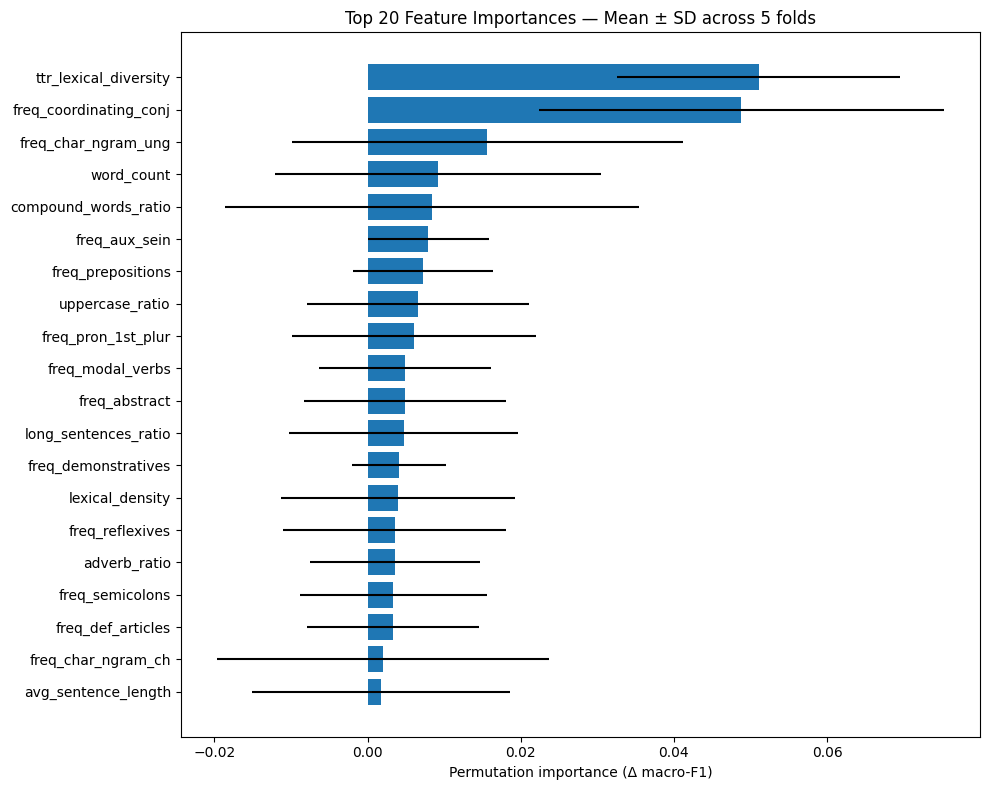

In [ ]:
# --- Step 2: single pass over the outer folds ---
# Collects out-of-fold predictions, per-fold scores, and per-fold
# permutation importances together, so everything below is computed
# from the exact same 5 fold-models.
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = np.empty_like(y)
fold_scores = []
fold_importances = []

for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
    X_train_fold = X.iloc[train_idx] if hasattr(X, "iloc") else X[train_idx]
    X_test_fold  = X.iloc[test_idx]  if hasattr(X, "iloc") else X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    fold_pipeline = clone(pipeline)
    fold_pipeline.fit(X_train_fold, y_train_fold)

    fold_pred = fold_pipeline.predict(X_test_fold)
    y_pred_cv[test_idx] = fold_pred

    score = f1_score(y_test_fold, fold_pred, average="macro")
    fold_scores.append(score)

    perm = permutation_importance(
        fold_pipeline, X_test_fold, y_test_fold,
        scoring="f1_macro", n_repeats=20, random_state=42, n_jobs=-1
    )
    fold_importances.append(perm.importances_mean)

    print(f"Fold {fold_i}: macro-F1 = {score:.3f}")

print(f"\nMean macro-F1: {np.mean(fold_scores):.3f}  (± {np.std(fold_scores):.3f})")

# --- Step 3: pooled out-of-fold performance on the full dataset ---
print("\n--- 5-fold stratified CV, out-of-fold predictions on full dataset ---")
print("NOTE: hyperparameters were tuned on the full dataset (same data used")
print("for OOF evaluation), so this estimate is mildly optimistic relative")
print("to the nested-CV estimate — treat it as a stability/diagnostic check,")
print("not the headline generalization number.")
print(f"Accuracy: {accuracy_score(y, y_pred_cv):.3f}")
print(f"Macro-F1: {f1_score(y, y_pred_cv, average='macro'):.3f}")
print(classification_report(y, y_pred_cv, zero_division=0))
print(confusion_matrix(y, y_pred_cv))

# --- Step 4: confusion matrices ---
classes = np.unique(y)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_cv, labels=classes, cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("OOF Confusion Matrix (Counts)", fontsize=12, fontweight="bold")
axes[0].grid(False)

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_cv, labels=classes, normalize="true",
    values_format=".2%", cmap="Blues", ax=axes[1], colorbar=True
)
axes[1].set_title("OOF Confusion Matrix (Normalised by True Class)", fontsize=12, fontweight="bold")
axes[1].grid(False)

plt.tight_layout()
plt.savefig("09_confusion_matrix_oof.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Step 5: feature importance, aggregated across the same 5 folds ---
imp_matrix = np.vstack(fold_importances)
imp_mean = pd.Series(imp_matrix.mean(axis=0), index=feature_names)
imp_std  = pd.Series(imp_matrix.std(axis=0), index=feature_names)

summary = pd.DataFrame({"mean_importance": imp_mean, "std_importance": imp_std})
summary = summary.sort_values("mean_importance", ascending=False)

print("\nTop 20 features (permutation importance, mean ± SD across folds):")
display(summary.head(20))

top20 = summary.head(20).sort_values("mean_importance")
plt.figure(figsize=(10, 8))
plt.barh(top20.index, top20["mean_importance"], xerr=top20["std_importance"])
plt.xlabel("Permutation importance (Δ macro-F1)")
plt.title("Top 20 Feature Importances — Mean ± SD across 5 folds")
plt.tight_layout()
plt.savefig("08_feature_importances.png", dpi=300, bbox_inches="tight")
plt.show()

## **5. Prediction**

In [ ]:
# Prediction for disputed / unattributed fragments
def predict_fragments(fragments_to_predict, category_name):
    records = []
    for num in fragments_to_predict:
        if num not in fragment_texts:
            continue
        row = extract_manual_features(fragment_texts[num])
        row.update(extract_stanza_features(fragment_texts[num]))
        X_pred = pd.DataFrame([row]).reindex(columns=feature_names, fill_value=0)
        pred = best_model.predict(X_pred)[0]
        proba = best_model.predict_proba(X_pred)[0]
        record = {
            "Fragment": num,
            "Original_Category": category_name,
            "Prediction": pred,
            "Confidence": float(proba.max())
        }
        record.update({f"Prob_{cls}": float(p) for cls, p in zip(best_model.classes_, proba)})
        records.append(record)
    return pd.DataFrame(records)

results_disputed = predict_fragments(attributions.get("Disputed", []), "Disputed")
results_unattributed = predict_fragments(attributions.get("Unattributed", []), "Unattributed")
all_results = pd.concat([results_disputed, results_unattributed], ignore_index=True)
all_results = all_results.sort_values("Confidence", ascending=False).reset_index(drop=True)
all_results.to_csv("athenaeum_predictions_clean.csv", index=False, encoding="utf-8-sig")
display(all_results)

,Fragment,Original_Category,Prediction,Confidence,Prob_August,Prob_Friedrich,Prob_Novalis,Prob_Schleiermacher
0,196,Unattributed,Friedrich,0.529936,0.197981,0.529936,0.079583,0.192500
1,425,Unattributed,Friedrich,0.483361,0.248222,0.483361,0.131417,0.137000
2,29,Unattributed,Novalis,0.476333,0.126333,0.178708,0.476333,0.218625
3,361,Disputed,August,0.456846,0.456846,0.290241,0.052667,0.200246
4,394,Disputed,Friedrich,0.455380,0.375370,0.455380,0.041417,0.127833
...,...,...,...,...,...,...,...,...
71,268,Unattributed,August,0.282958,0.282958,0.207875,0.273958,0.235208
72,248,Unattributed,Friedrich,0.282208,0.256306,0.282208,0.197722,0.263764
73,158,Disputed,Schleiermacher,0.276982,0.238921,0.212708,0.271389,0.276982
74,213,Unattributed,Novalis,0.272250,0.255750,0.222083,0.272250,0.249917
